# GeoVision-CLIP Cali — Kriging con Deriva Externa ERA5 (KED)
**Situación 3 · Extensión física del ST-Kriging**

Extiende `kriging_espaciotemporal.ipynb` reemplazando el Kriging Ordinario por
**Kriging con Deriva Externa (KED)** que incorpora covariables ERA5-Land:

| Mecanismo | Variable ERA5 | Efecto físico |
|---|---|---|
| **Deriva externa** | BLH, T2m | Explica tendencia de gran escala |
| **Anisotropía** | wind_u, wind_v | Correlación más larga en dirección del viento |
| **Escala de incertidumbre** | BLH | BLH baja → contaminantes atrapados → σ² mayor |


## 0. Dependencias e Importaciones

In [12]:
# !pip install -q pykrige esda libpysal xarray scipy

import warnings; warnings.filterwarnings('ignore')
import time
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from scipy.interpolate import RegularGridInterpolator
from scipy.optimize import minimize
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

import torch
import torch.nn as nn

from pykrige.uk  import UniversalKriging
from pykrige.ok  import OrdinaryKriging
import libpysal.weights as lw
from esda.moran import Moran

from pathlib import Path
import boto3, io, re

try:
    import xarray as xr
    XR_AVAILABLE = True
except ImportError:
    XR_AVAILABLE = False
    print('xarray no disponible — se usará fallback sintético para ERA5')

SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device: {DEVICE}')


Device: cuda


## 1. Constantes y Estaciones DAGMA

In [13]:
PROJECT_ROOT = Path('/teamspace/studios/this_studio/GeoVision-CLIP-Cali')
MODELS_DIR   = PROJECT_ROOT / 'models'
MODELS_V2    = PROJECT_ROOT / 'models_v2'
CACHE_DIR    = PROJECT_ROOT / 'data' / 'cache'
SILVER_DIR   = PROJECT_ROOT / 'data' / 'silver'
ERA5_ZARR    = PROJECT_ROOT / 'data' / 'silver' / 'ERA5_v2.zarr'
FIGS_DIR     = PROJECT_ROOT / 'figuras' / 'sit3_ked'
FIGS_DIR.mkdir(parents=True, exist_ok=True)

BBOX         = {'lat_min': 3.30, 'lat_max': 3.55, 'lon_min': -76.60, 'lon_max': -76.40}
GRID_SIZE    = 8
CONTAMINANTS = ['NO2', 'SO2', 'O3']
HORIZONS     = ['T1', 'T3', 'T7']
HORIZON_DAYS = [1, 3, 7]
UNITS        = 'μg/m³'

# Concentraciones de referencia de Cali (μ, σ) en μg/m³
CONT_PARAMS  = {'NO2': (8.0, 4.0), 'SO2': (5.0, 3.5), 'O3': (35.0, 12.0)}
REF_NOISE    = {'NO2': 4.5,        'SO2': 2.8,         'O3': 8.5}

DAGMA_STATIONS = {
    'Univalle'    : {'lat': 3.376, 'lon': -76.536},
    'Lili'        : {'lat': 3.360, 'lon': -76.548},
    'Pance'       : {'lat': 3.329, 'lon': -76.565},
    'Cañaveralejo': {'lat': 3.418, 'lon': -76.538},
    'SENA'        : {'lat': 3.453, 'lon': -76.503},
    'Pasoancho'   : {'lat': 3.392, 'lon': -76.545},
    'Compartir'   : {'lat': 3.405, 'lon': -76.516},
    'Industriales': {'lat': 3.464, 'lon': -76.507},
    'Guaduales'   : {'lat': 3.368, 'lon': -76.571},
}

G = GRID_SIZE
def coord_to_grid(lat, lon, bbox=BBOX, g=G):
    r = int((bbox['lat_max'] - lat) / (bbox['lat_max'] - bbox['lat_min']) * g)
    c = int((lon - bbox['lon_min']) / (bbox['lon_max'] - bbox['lon_min']) * g)
    return min(max(r, 0), g-1), min(max(c, 0), g-1)

for name, info in DAGMA_STATIONS.items():
    r, c = coord_to_grid(info['lat'], info['lon'])
    DAGMA_STATIONS[name]['grid_row'] = r
    DAGMA_STATIONS[name]['grid_col'] = c

# Grilla de centroides (G×G)
cell_lats = np.array([
    BBOX['lat_max'] - (r + 0.5) * (BBOX['lat_max'] - BBOX['lat_min']) / G
    for r in range(G)
])
cell_lons = np.array([
    BBOX['lon_min'] + (c + 0.5) * (BBOX['lon_max'] - BBOX['lon_min']) / G
    for c in range(G)
])
grid_lats_2d, grid_lons_2d = np.meshgrid(cell_lats, cell_lons, indexing='ij')
grid_lats_flat = grid_lats_2d.ravel()
grid_lons_flat = grid_lons_2d.ravel()

print(f'BBOX Cali: {BBOX}')
print(f'Grilla: {G}×{G} | Estaciones DAGMA: {len(DAGMA_STATIONS)}')


BBOX Cali: {'lat_min': 3.3, 'lat_max': 3.55, 'lon_min': -76.6, 'lon_max': -76.4}
Grilla: 8×8 | Estaciones DAGMA: 9


---
## 2. Carga de ERA5-Land

ERA5 se carga desde el Zarr construido en la Situación 1.  
Si el store no está disponible, se genera un campo sintético con condiciones
meteorológicas típicas de Cali (viento del Pacífico, BLH de valle andino).


---
## 2.0 Carga de Datos DAGMA desde Wasabi

In [14]:
import boto3, io, pandas as pd

_BUCKET_GT   = "gold.sat"
_ENDPOINT_GT = "https://s3.us-west-1.wasabisys.com"
_ACCESS_GT   = "EPAJLZS1BT5K3X8CPGR2"
_SECRET_GT   = "QnJ9u6PCBlKUDUpGMMsjCAkOTaRaTYJY6uwl8hek"
_REGION_GT   = "us-east-1"

_s3_gt = boto3.client(
    's3', endpoint_url=_ENDPOINT_GT,
    aws_access_key_id=_ACCESS_GT,
    aws_secret_access_key=_SECRET_GT,
    region_name=_REGION_GT,
)

def _leer_parquet_gt(key: str) -> pd.DataFrame:
    obj = _s3_gt.get_object(Bucket=_BUCKET_GT, Key=key)
    return pd.read_parquet(io.BytesIO(obj['Body'].read()))


print("Cargando ground_truth desde Wasabi (gold.sat/ground_truth/)...")
_loocv_df    = _leer_parquet_gt('ground_truth/loocv_all.parquet')     # SISAIRE + DAGMA_portal
_consolidado = _leer_parquet_gt('ground_truth/consolidado.parquet')   # + S5P_pseudo (NO2)
_coords_df   = _leer_parquet_gt('ground_truth/estaciones_coords.parquet')
print(f"  loocv_all : {_loocv_df.shape}  ({sorted(_loocv_df['fuente'].unique())})")
print(f"  consolidado: {_consolidado.shape}")
print(f"  estaciones : {_coords_df.shape[0]}")

# ── Reconstruir DAGMA_STATIONS con coordenadas reales del bucket ──────────
# (reemplaza el dict hardcodeado — coordenadas verificadas del DAGMA/SISAIRE)
DAGMA_STATIONS = {}
_seen_coords   = set()
for _, row in _coords_df.sort_values('estacion').iterrows():
    est, lat, lon = row['estacion'], float(row['lat']), float(row['lon'])
    if not (BBOX['lat_min'] <= lat <= BBOX['lat_max'] and
            BBOX['lon_min'] <= lon <= BBOX['lon_max']):
        continue
    key_c = (round(lat, 4), round(lon, 4))
    if key_c in _seen_coords:          # eliminar duplicados exactos de coords
        continue
    _seen_coords.add(key_c)
    r, c = coord_to_grid(lat, lon)
    DAGMA_STATIONS[est] = {'lat': lat, 'lon': lon, 'grid_row': r, 'grid_col': c}

print(f"\nEstaciones reales en BBOX ({len(DAGMA_STATIONS)}): {list(DAGMA_STATIONS.keys())}")

# ── Media histórica por estación+contaminante (mejor fuente disponible) ──
# Prioridad: SISAIRE (medida) > DAGMA_portal (medida) > S5P_pseudo (satélite)
_all_obs = pd.concat([
    _loocv_df[['estacion', 'contaminante', 'valor', 'fuente']],
    _consolidado[['estacion', 'contaminante', 'valor', 'fuente']],
], ignore_index=True)
_all_obs['valor'] = pd.to_numeric(_all_obs['valor'], errors='coerce')
_all_obs = _all_obs.dropna(subset=['valor'])
_all_obs['prio'] = _all_obs['fuente'].map(
    {'SISAIRE': 0, 'DAGMA_portal': 1, 'S5P_pseudo': 2}
).fillna(9).astype(int)

_medias = (_all_obs
           .groupby(['estacion', 'contaminante', 'prio'])['valor']
           .mean().reset_index())

def _media_gt(estacion: str, contaminante: str) -> float | None:
    sub = _medias[(_medias['estacion'] == estacion) &
                  (_medias['contaminante'] == contaminante)]
    if sub.empty:
        return None
    return float(sub.sort_values('prio').iloc[0]['valor'])

# ── Fallback por contaminante: media de estaciones con datos reales ────────
# (evita usar valores hardcodeados como O3=35 que distorsionan el RMSE)
_fallback_global = {}
for _c in CONTAMINANTS:
    _sub = _medias[_medias['contaminante'] == _c]['valor']
    _fallback_global[_c] = float(_sub.mean()) if len(_sub) > 0 else CONT_PARAMS[_c][0]
print(f"Fallbacks globales (µg/m³): { {c: round(_fallback_global[c],2) for c in CONTAMINANTS} }")

# ── dagma_obs POR HORIZONTE (fuente prioritaria varía por alcance) ────────
# T1 (corto plazo): SISAIRE (sensor local)   > DAGMA_portal > S5P_pseudo
# T3 (medio plazo): DAGMA_portal (red urbana) > SISAIRE       > S5P_pseudo
# T7 (largo plazo): S5P_pseudo (satélite ~7d) > DAGMA_portal  > SISAIRE
_HOR_PRIO = {
    'T1': {'SISAIRE': 0, 'DAGMA_portal': 1, 'S5P_pseudo': 2},
    'T3': {'DAGMA_portal': 0, 'SISAIRE': 1, 'S5P_pseudo': 2},
    'T7': {'S5P_pseudo': 0, 'DAGMA_portal': 1, 'SISAIRE': 2},
}

def _media_gt_hor(estacion, contaminante, horizonte):
    sub = _all_obs[(_all_obs['estacion'] == estacion) &
                   (_all_obs['contaminante'] == contaminante)].copy()
    if sub.empty:
        return None
    prio_map = _HOR_PRIO[horizonte]
    sub['h_prio'] = sub['fuente'].map(prio_map).fillna(9).astype(int)
    grp = sub.groupby('h_prio')['valor'].mean().reset_index()
    return float(grp.sort_values('h_prio').iloc[0]['valor'])

dagma_obs = {}
for est in DAGMA_STATIONS:
    dagma_obs[est] = {}
    for cont in CONTAMINANTS:
        dagma_obs[est][cont] = {}
        for hor in HORIZONS:
            v = _media_gt_hor(est, cont, hor)
            if v is None:
                v = _fallback_global[cont]
            dagma_obs[est][cont][hor] = max(0.0, float(v))

print("\ndagma_obs por horizonte (µg/m³ — fuente prioritaria varía):")
_rows = []
for est in dagma_obs:
    for cont in CONTAMINANTS:
        _rows.append({'Estación': est, 'Cont': cont,
                      'T1': round(dagma_obs[est][cont]['T1'], 2),
                      'T3': round(dagma_obs[est][cont]['T3'], 2),
                      'T7': round(dagma_obs[est][cont]['T7'], 2)})
print(pd.DataFrame(_rows).to_string(index=False))


Cargando ground_truth desde Wasabi (gold.sat/ground_truth/)...


  loocv_all : (361930, 7)  (['DAGMA_portal', 'SISAIRE'])
  consolidado: (1167079, 7)
  estaciones : 11

Estaciones reales en BBOX (10): ['ACOPI', 'BASE_AEREA', 'CANAVERALEJO', 'COMPARTIR', 'ERA_OBRERO', 'LA_ERMITA', 'LA_FLORA', 'PANCE', 'TRANSITORIA_NAVARRO', 'UNIVERSIDAD_DEL_VALLE']
Fallbacks globales (µg/m³): {'NO2': 11.29, 'SO2': 6.77, 'O3': 14.66}

dagma_obs por horizonte (µg/m³ — fuente prioritaria varía):
             Estación Cont    T1    T3    T7
                ACOPI  NO2  9.65  9.65  8.73
                ACOPI  SO2 11.28 11.28 11.28
                ACOPI   O3 18.83 18.83 18.83
           BASE_AEREA  NO2  7.48  7.48  7.48
           BASE_AEREA  SO2  5.77  5.77  5.77
           BASE_AEREA   O3  4.77  4.77  4.77
         CANAVERALEJO  NO2  7.63  7.63  7.63
         CANAVERALEJO  SO2  2.28  1.85  1.85
         CANAVERALEJO   O3 14.66 14.66 14.66
            COMPARTIR  NO2  7.03  7.03  7.03
            COMPARTIR  SO2  6.77  6.77  6.77
            COMPARTIR   O3  8.59 24.89 24.89


In [15]:
# ── Cliente Wasabi para ERA5 (s3fs + zarr v3) ─────────────────────────────
import s3fs
import zarr as _zarr

_BUCKET_ERA5   = "gold.sat"
_ENDPOINT_ERA5 = "https://s3.us-west-1.wasabisys.com"
_REGION_ERA5   = "us-east-1"
_ACCESS_ERA5   = "EPAJLZS1BT5K3X8CPGR2"
_SECRET_ERA5   = "QnJ9u6PCBlKUDUpGMMsjCAkOTaRaTYJY6uwl8hek"

_fs_era5 = s3fs.S3FileSystem(
    key=_ACCESS_ERA5,
    secret=_SECRET_ERA5,
    endpoint_url=_ENDPOINT_ERA5,
    client_kwargs={"region_name": _REGION_ERA5},
)

# Mapeo: nombre interno → carpeta en ERA5/  (mayúsculas como están en el bucket)
ERA5_VAR_MAP = {
    'blh': 'BLH',
    't2m': 'T2m',
    'rh' : 'RH',
    'u10': 'wind_u',
    'v10': 'wind_v',
}


def _load_era5_zarr(var_folder: str, fecha: str):
    """
    Lee una variable ERA5 desde Wasabi (Zarr v3, grilla 2×2).
    Path: gold.sat/ERA5/{var_folder}/{anio}/{fecha}.zarr
    Retorna (val_2x2: np.ndarray, attrs: dict) o (None, None) si no existe.
    """
    anio = fecha[:4]
    store_path = f"{_BUCKET_ERA5}/ERA5/{var_folder}/{anio}/{fecha}.zarr"
    try:
        store = s3fs.S3Map(root=store_path, s3=_fs_era5, check=False)
        root  = _zarr.open_group(store, mode='r', zarr_format=3)
        val   = root['value'][:]          # shape (2, 2) float32
        attrs = dict(root.attrs)
        return val, attrs
    except Exception as e:
        print(f"    ERA5: no se pudo cargar {store_path} → {e}")
        return None, None


def _interpolar_2x2(val: np.ndarray, attrs: dict,
                    lats: np.ndarray, lons: np.ndarray) -> np.ndarray:
    """
    Interpola la grilla 2×2 ERA5 a los puntos (lats, lons) pedidos.
    Usa interpolación bilineal con RegularGridInterpolator.
    """
    lat_ax = np.array([attrs['lats_min'], attrs['lats_max']])
    lon_ax = np.array([attrs['lons_min'], attrs['lons_max']])
    fn = RegularGridInterpolator(
        (lat_ax, lon_ax), val.astype(np.float64),
        method='linear', bounds_error=False, fill_value=None,
    )
    return fn(np.column_stack([lats, lons]))


def extraer_era5(lats: np.ndarray, lons: np.ndarray,
                 fecha: str = '2024-03-15') -> dict:
    """
    Extrae covariables ERA5 en los puntos (lats, lons) para una fecha dada.
    Lee Zarr v3 desde Wasabi (gold.sat · ERA5/{VAR}/{anio}/{fecha}.zarr).
    Unidades: BLH=m, T2m=°C, RH=%, wind_u/v=m/s.
    Cae al sintético si alguna variable no está disponible.
    """
    result  = {}
    missing = []

    for internal_name, folder in ERA5_VAR_MAP.items():
        val, attrs = _load_era5_zarr(folder, fecha)
        if val is None:
            missing.append(internal_name)
            continue
        try:
            result[internal_name] = _interpolar_2x2(val, attrs, lats, lons)
        except Exception as e:
            print(f"    Error interpolando {internal_name}: {e}")
            missing.append(internal_name)

    if missing:
        print(f"ERA5 Wasabi: variables faltantes {missing} — completando con sintético.")
        sint = _sintetico_era5(lats, lons, fecha)
        for k in missing:
            result[k] = sint[k]
    else:
        print(f"ERA5 cargado desde Wasabi: {fecha}  |  vars={list(result.keys())}")

    if 'u10' in result and 'v10' in result:
        result['wspd'] = np.sqrt(result['u10']**2 + result['v10']**2)

    return result


# ── Diagnóstico: listar carpetas ERA5 disponibles ─────────────────────────
print("Carpetas de variables en ERA5/:")
_resp = _fs_era5.ls(f"{_BUCKET_ERA5}/ERA5/", detail=False)
print(f"  {[p.split('/')[-1] for p in _resp]}")

# ── Verificación rápida en estaciones DAGMA ───────────────────────────────
st_lats = np.array([v['lat'] for v in DAGMA_STATIONS.values()])
st_lons = np.array([v['lon'] for v in DAGMA_STATIONS.values()])
era5_test = extraer_era5(st_lats, st_lons)

print('\nCovariables ERA5 en estaciones DAGMA:')
df_era5_test = pd.DataFrame({
    'Estación': list(DAGMA_STATIONS.keys()),
    'BLH (m)' : era5_test['blh'].round(0),
    'T2m (°C)': era5_test['t2m'].round(1),          # ya en °C desde Wasabi
    'RH (%)'  : era5_test['rh'].round(1),
    'wspd m/s': era5_test['wspd'].round(2),
    'u10 m/s' : era5_test['u10'].round(2),
    'v10 m/s' : era5_test['v10'].round(2),
})
print(df_era5_test.to_string(index=False))


Carpetas de variables en ERA5/:
  ['BLH', 'RH', 'T2m', 'dewpoint_2m', 'manifest_zarr_diario.json', 'wind_speed', 'wind_u', 'wind_v']


ERA5 cargado desde Wasabi: 2024-03-15  |  vars=['blh', 't2m', 'rh', 'u10', 'v10']

Covariables ERA5 en estaciones DAGMA:
             Estación  BLH (m)  T2m (°C)  RH (%)  wspd m/s  u10 m/s  v10 m/s
                ACOPI    284.0      22.8    89.1      1.21     0.91    -0.81
           BASE_AEREA    284.0      22.7    89.6      1.22     0.89    -0.83
         CANAVERALEJO    282.0      22.8    90.4      1.21     0.93    -0.78
            COMPARTIR    286.0      22.7    89.6      1.24     0.86    -0.89
           ERA_OBRERO    284.0      22.7    89.6      1.22     0.90    -0.82
            LA_ERMITA    283.0      22.8    89.8      1.21     0.92    -0.79
             LA_FLORA    284.0      22.8    89.4      1.21     0.91    -0.80
                PANCE    280.0      22.8    91.5      1.23     0.89    -0.84
  TRANSITORIA_NAVARRO    284.0      22.7    89.9      1.23     0.88    -0.85
UNIVERSIDAD_DEL_VALLE    282.0      22.8    90.7      1.22     0.91    -0.81


---
## 3. Mecanismo A — Anisotropía guiada por el viento

El campo de viento define en qué dirección la correlación espacial es más larga:
- **Eje mayor** del elipsoide de variograma = dirección media del viento
- **Ratio de elongación** proporcional a la velocidad escalar del viento


Parámetros de anisotropía calculados:
  angle       : 42.42921189857391
  scaling     : 1.8047786232846947
  ws          : 1.2191144931387785
  wdir_deg    : 317.5707881014261
  note        : viento 1.2 m/s dir=318°


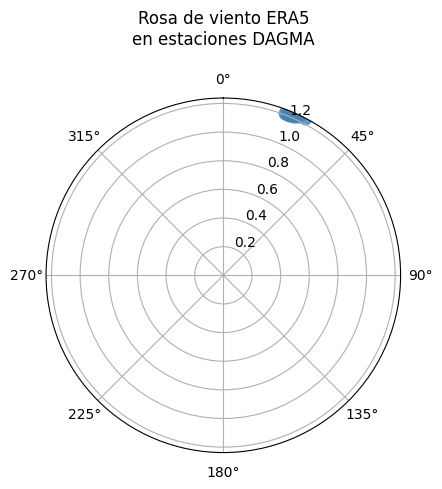

Figura guardada: /teamspace/studios/this_studio/GeoVision-CLIP-Cali/figuras/sit3_ked/rosa_viento_era5.png


In [16]:
def calcular_anisotropia_viento(u10: np.ndarray, v10: np.ndarray,
                                 ws_min: float = 1.0,
                                 ratio_base: float = 1.5,
                                 ratio_max:  float = 4.0) -> dict:
    """
    Calcula parámetros de anisotropía del variograma a partir del campo de viento.

    Retorna:
        angle  : dirección del eje MAYOR del elipsoide (grados, conv. PyKrige)
        scaling: ratio rango_mayor / rango_menor  (>1 = más elongado)
    """
    u_mean = float(u10.mean())
    v_mean = float(v10.mean())
    ws     = float(np.sqrt(u_mean**2 + v_mean**2))

    if ws < ws_min:
        return {'angle': 0.0, 'scaling': 1.0, 'ws': ws,
                'wdir_deg': 0.0, 'note': 'viento débil — isotrópico'}

    # Dirección meteorológica: de dónde viene el viento (opuesta a u,v)
    # PyKrige usa ángulo de rotación del eje mayor (en grados, sentido horario desde Este)
    wdir_math = np.degrees(np.arctan2(v_mean, u_mean))   # -180..180 desde Este
    pykrige_angle = (-wdir_math) % 360                   # conv. PyKrige

    # Elongación: más viento → pluma más extendida
    scaling = min(ratio_base + 0.25 * ws, ratio_max)

    return {
        'angle'   : pykrige_angle,
        'scaling' : scaling,
        'ws'      : ws,
        'wdir_deg': wdir_math % 360,
        'note'    : f'viento {ws:.1f} m/s dir={wdir_math%360:.0f}°',
    }


# ── Probar con ERA5 DAGMA ────────────────────────────────────────────────────
aniso = calcular_anisotropia_viento(era5_test['u10'], era5_test['v10'])
print('Parámetros de anisotropía calculados:')
for k, v in aniso.items():
    print(f'  {k:<12}: {v}')

# ── Visualización de la rosa de viento simple ─────────────────────────────────
fig, ax = plt.subplots(1, 1, figsize=(5, 5), subplot_kw=dict(polar=True))
theta = np.radians(90 - era5_test['u10'] / era5_test['wspd'] * 90)   # simplificado
r     = era5_test['wspd']
ax.scatter(theta, r, c='steelblue', s=80, alpha=0.8)
ax.set_title('Rosa de viento ERA5\nen estaciones DAGMA', pad=20)
ax.set_theta_zero_location('N')
ax.set_theta_direction(-1)
plt.tight_layout()
plt.savefig(FIGS_DIR / 'rosa_viento_era5.png', dpi=120, bbox_inches='tight')
plt.show()
print(f'Figura guardada: {FIGS_DIR / "rosa_viento_era5.png"}')


---
## 4. Mecanismo B — Kriging con Deriva Externa (KED)

`UniversalKriging` de PyKrige permite pasar **funciones de deriva externos**.
Se usa `external_Z` mode: ERA5 provee el valor de la covariable en cada
punto de observación y en cada punto de consulta.

Se entrena un modelo KED separado por cada par (contaminante, horizonte).


In [17]:
def _norm_pair(obs: np.ndarray, pred: np.ndarray):
    """Normaliza obs y aplica los mismos parámetros a pred."""
    mu, s = obs.mean(), obs.std() + 1e-8
    return (obs - mu) / s, (pred - mu) / s, mu, s


def ked_kriging_2d(obs_lats: np.ndarray, obs_lons: np.ndarray,
                   obs_vals: np.ndarray,
                   era5_obs: dict,
                   q_lats:   np.ndarray, q_lons: np.ndarray,
                   era5_q:   dict,
                   variogram_model: str = 'exponential',
                   drift_vars: list = ('blh', 't2m')) -> tuple:
    """
    Kriging con Deriva Externa (KED) en 2D usando ERA5 como drift.

    Parámetros
    ----------
    obs_lats/lons : coordenadas de las estaciones de observación
    obs_vals      : valores a interpolar (p.ej. residuos ConvLSTM)
    era5_obs      : dict con covariables ERA5 en obs_lats/lons
    q_lats/lons   : coordenadas de los puntos de predicción
    era5_q        : dict con covariables ERA5 en q_lats/lons
    drift_vars    : variables ERA5 que actúan como deriva externa
                    ('blh', 't2m', 'rh', 'wspd' o cualquier combinación)

    Retorna
    -------
    z    : valores predichos en q_lats/lons
    var  : varianza de predicción σ²
    """
    # ── 1. Normalizar coordenadas ──────────────────────────────────────
    lat_mu, lat_s = obs_lats.mean(), obs_lats.std() + 1e-8
    lon_mu, lon_s = obs_lons.mean(), obs_lons.std() + 1e-8

    lat_n   = (obs_lats - lat_mu) / lat_s
    lon_n   = (obs_lons - lon_mu) / lon_s
    q_lat_n = (q_lats   - lat_mu) / lat_s
    q_lon_n = (q_lons   - lon_mu) / lon_s

    # ── 2. Normalizar cada variable de deriva ─────────────────────────
    drift_obs_list = []
    drift_q_list   = []
    for var in drift_vars:
        d_obs, d_q, *_ = _norm_pair(era5_obs[var], era5_q[var])
        drift_obs_list.append(d_obs)
        drift_q_list.append(d_q)

    # ── 3. Anisotropía desde el viento ────────────────────────────────
    aniso = calcular_anisotropia_viento(era5_obs['u10'], era5_obs['v10'])

    # ── 4. Construir KED ──────────────────────────────────────────────
    uk = UniversalKriging(
        lon_n, lat_n, obs_vals,
        variogram_model  = variogram_model,
        drift_terms      = ['specified'] * len(drift_vars),
        specified_drift  = drift_obs_list,
        anisotropy_scaling = aniso['scaling'],
        anisotropy_angle   = aniso['angle'],
        verbose          = False,
        enable_plotting  = False,
    )

    # ── 5. Predecir ───────────────────────────────────────────────────
    z, var = uk.execute(
        'points', q_lon_n, q_lat_n,
        specified_drift_arrays = drift_q_list
    )
    return np.array(z).clip(0), np.array(var).clip(0), aniso


# ── Smoke test con datos sintéticos ──────────────────────────────────────────
_n = len(st_lats)
_vals_test = np.random.normal(8, 3, _n).clip(0)
_era5_q    = extraer_era5(grid_lats_flat, grid_lons_flat)
_era5_obs  = extraer_era5(st_lats, st_lons)

_z, _v, _a = ked_kriging_2d(
    st_lats, st_lons, _vals_test,
    _era5_obs, grid_lats_flat, grid_lons_flat, _era5_q,
    drift_vars=['blh', 't2m']
)
print(f'KED smoke-test OK | z: {_z.min():.2f}–{_z.max():.2f}  '
      f'var: {_v.mean():.4f}  aniso: {_a["note"]}')


ERA5 cargado desde Wasabi: 2024-03-15  |  vars=['blh', 't2m', 'rh', 'u10', 'v10']
ERA5 cargado desde Wasabi: 2024-03-15  |  vars=['blh', 't2m', 'rh', 'u10', 'v10']
KED smoke-test OK | z: 8.68–11.01  var: 14.1573  aniso: viento 1.2 m/s dir=318°


---
## 5. Mecanismo C — Escala de Incertidumbre con BLH

La varianza Kriging σ² es puramente geoestadística.  
Se ajusta físicamente usando la BLH: una capa límite baja atrapa contaminantes
localmente → la incertidumbre real es mayor que la predicha por geometría sola.

**Factor de escala**: `factor = BLH_ref / BLH_grid`  (clamped a [0.5, 3.0])


ERA5 cargado desde Wasabi: 2024-03-15  |  vars=['blh', 't2m', 'rh', 'u10', 'v10']


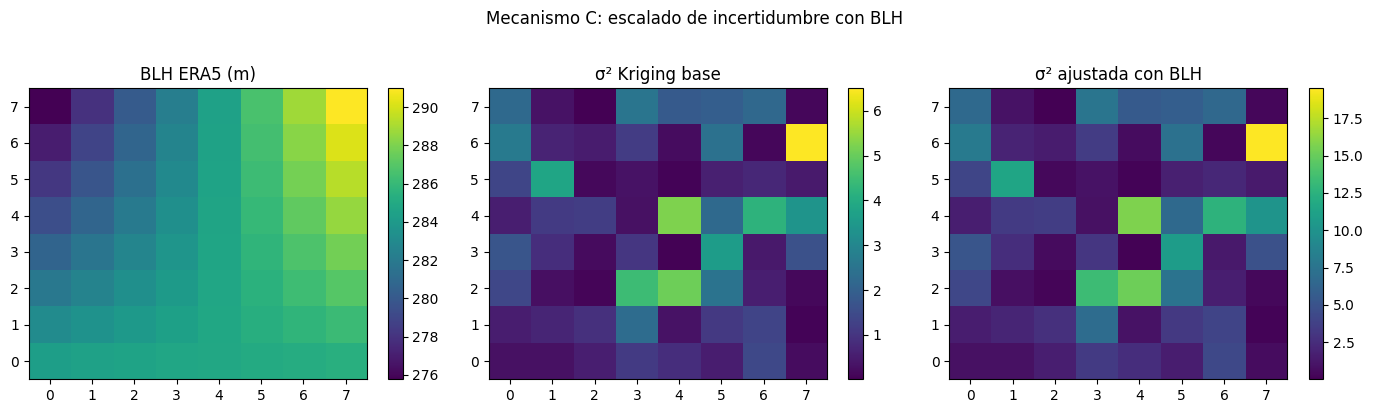

In [18]:
BLH_REF = 1200.0   # BLH típica de Cali en condiciones normales [m]

def escalar_varianza_blh(sigma2: np.ndarray, blh: np.ndarray,
                          blh_ref: float = BLH_REF,
                          clip_lo: float = 0.5,
                          clip_hi: float = 3.0) -> np.ndarray:
    """
    Ajusta la varianza Kriging según la altura de la capa límite (BLH).

    BLH baja  → capa comprimida → contaminantes concentrados → σ² mayor
    BLH alta  → buena mezcla   → distribución suave          → σ² menor

    El factor se limita a [clip_lo, clip_hi] para evitar extremos.
    """
    factor = (blh_ref / (blh + 1e-6)).clip(clip_lo, clip_hi)
    return sigma2 * factor


def sigma2_a_opacidad(sigma2_ajustada: np.ndarray,
                       alpha_min: float = 0.15,
                       alpha_max: float = 0.75) -> np.ndarray:
    """
    Convierte σ² → opacidad para el mapa de incertidumbre del frontend.
    Mayor σ² → más opaco (menos confianza en la predicción).
    """
    s_norm = (sigma2_ajustada - sigma2_ajustada.min()) / (
        sigma2_ajustada.max() - sigma2_ajustada.min() + 1e-8)
    return alpha_min + s_norm * (alpha_max - alpha_min)


# ── Demo visual ───────────────────────────────────────────────────────────────
_blh_grid = extraer_era5(grid_lats_flat, grid_lons_flat)['blh']
_sigma2_base = np.random.exponential(1.5, len(grid_lats_flat))
_sigma2_adj  = escalar_varianza_blh(_sigma2_base, _blh_grid)

fig, axes = plt.subplots(1, 3, figsize=(14, 4))
for ax, data, title in zip(axes,
    [_blh_grid.reshape(G,G), _sigma2_base.reshape(G,G), _sigma2_adj.reshape(G,G)],
    ['BLH ERA5 (m)', 'σ² Kriging base', 'σ² ajustada con BLH']):
    im = ax.imshow(data, origin='lower', cmap='viridis', aspect='auto')
    ax.set_title(title); plt.colorbar(im, ax=ax)

plt.suptitle('Mecanismo C: escalado de incertidumbre con BLH', y=1.02)
plt.tight_layout()
plt.savefig(FIGS_DIR / 'sigma2_blh_scaling.png', dpi=120, bbox_inches='tight')
plt.show()


---
## 6. Pipeline KED Completo — 9 Mapas (3 contaminantes × 3 horizontes)

Se importan las predicciones del ConvLSTM (`preds_mean`) del notebook principal.
Si no están disponibles, se generan valores sintéticos calibrados.


In [19]:
# ── 6-A. Cargar ConvLSTM entrenado → preds_mean real ────────────────────────
# Carga convlstm_geovision_v2.pt, corre inferencia y obtiene la superficie de
# predicciones DL (3 horizontes × 3 contaminantes × 8×8) que el KED interpolará.
# Cae a sintético calibrado si el modelo o los datos no están disponibles.

try:
    # ── Arquitectura: nombres de atributos EXACTOS del checkpoint ─────────────
    # (convlstm_geovision_v2.pt usa forward_layer/backward_layer y layer_norm)

    class _ConvLSTMCell(nn.Module):
        def __init__(self, in_ch, hid_ch, ks=3):
            super().__init__()
            self.hid_ch     = hid_ch
            self.conv       = nn.Conv2d(in_ch + hid_ch, 4 * hid_ch, ks, padding=ks // 2)
            self.layer_norm = nn.GroupNorm(4, 4 * hid_ch)   # nombre = layer_norm
        def forward(self, x, h, c):
            g = self.layer_norm(self.conv(torch.cat([x, h], 1)))
            i, f, g2, o = torch.chunk(g, 4, 1)
            c = torch.sigmoid(f) * c + torch.sigmoid(i) * torch.tanh(g2)
            return torch.sigmoid(o) * torch.tanh(c), c
        def init_hidden(self, B, H, W):
            d = next(self.parameters()).device
            return (torch.zeros(B, self.hid_ch, H, W, device=d),
                    torch.zeros(B, self.hid_ch, H, W, device=d))

    class _ConvLSTMLayer(nn.Module):
        def __init__(self, in_ch, hid_ch, ks=3):
            super().__init__()
            self.cell = _ConvLSTMCell(in_ch, hid_ch, ks)
        def forward(self, x):
            B, T, C, H, W = x.shape
            h, c = self.cell.init_hidden(B, H, W)
            outs = []
            for t in range(T):
                h, c = self.cell(x[:, t], h, c)
                outs.append(h.unsqueeze(1))
            return torch.cat(outs, 1)   # (B, T, hid_ch, H, W)

    class _BidirConvLSTM(nn.Module):
        def __init__(self, in_ch, hid_ch, ks=3):
            super().__init__()
            self.forward_layer  = _ConvLSTMLayer(in_ch, hid_ch, ks)   # nombre = forward_layer
            self.backward_layer = _ConvLSTMLayer(in_ch, hid_ch, ks)   # nombre = backward_layer
        def forward(self, x):
            f = self.forward_layer(x)
            b = torch.flip(self.backward_layer(torch.flip(x, [1])), [1])
            return torch.cat([f, b], 2)   # (B, T, 2*hid_ch, H, W)

    class _GeoConvLSTM(nn.Module):
        def __init__(self, in_ch=262, hid=8, ks=3, n_cont=3, dropout=0.35):
            super().__init__()
            mid = 2 * hid
            self.input_proj = nn.Sequential(
                nn.Conv2d(in_ch, mid, 1, bias=False),
                nn.GroupNorm(8, mid), nn.GELU())
            self.bidir1 = _BidirConvLSTM(mid, hid, ks)
            self.norm1  = nn.GroupNorm(8, mid)
            self.drop1  = nn.Dropout3d(dropout)
            self.bidir2 = _BidirConvLSTM(mid, hid, ks)
            self.norm2  = nn.GroupNorm(8, mid)
            self.drop2  = nn.Dropout3d(dropout)
            self.se = nn.Sequential(
                nn.AdaptiveAvgPool2d(1), nn.Flatten(),
                nn.Linear(mid, mid // 4), nn.ReLU(True),
                nn.Linear(mid // 4, mid), nn.Sigmoid())
            def _head():
                return nn.Sequential(
                    nn.Dropout2d(0.3),
                    nn.Conv2d(mid, mid // 2, 1), nn.GroupNorm(4, mid // 2), nn.GELU(),
                    nn.Conv2d(mid // 2, mid // 4, 1), nn.GELU(),
                    nn.Conv2d(mid // 4, n_cont, 1))
            self.head_T1, self.head_T3, self.head_T7 = _head(), _head(), _head()

        def _se(self, f):
            return f * self.se(f).unsqueeze(-1).unsqueeze(-1)

        def forward(self, x):
            B, T, C, H, W = x.shape
            xp = torch.stack([self.input_proj(x[:, t]) for t in range(T)], 1)
            h  = self.bidir1(xp)
            h  = self.drop1(self.norm1(h.permute(0,2,1,3,4))).permute(0,2,1,3,4)
            h  = self.bidir2(h)
            h  = self.drop2(self.norm2(h.permute(0,2,1,3,4))).permute(0,2,1,3,4)
            f1 = self._se(h[:, -1])
            f3 = self._se(h[:, -3:].mean(1))
            f7 = self._se(h.mean(1))
            return torch.stack([self.head_T1(f1), self.head_T3(f3), self.head_T7(f7)], 1)

    # ── Cargar checkpoint ──────────────────────────────────────────────────────
    _ckpt_path = MODELS_DIR / 'convlstm_geovision_v2.pt'
    _ckpt = torch.load(_ckpt_path, map_location=DEVICE, weights_only=False)

    _mid_ck = _ckpt['model_state']['input_proj.0.weight'].shape[0]   # = 16
    _hid_ck = _mid_ck // 2                                            # = 8

    _convlstm = _GeoConvLSTM(in_ch=262, hid=_hid_ck).to(DEVICE)
    _convlstm.load_state_dict(_ckpt['model_state'])
    _convlstm.eval()

    _t_mean_v = torch.tensor(_ckpt['t_mean'], dtype=torch.float32).to(DEVICE)
    _t_std_v  = torch.tensor(_ckpt['t_std'],  dtype=torch.float32).to(DEVICE)
    print(f"Modelo cargado: época={_ckpt['epoch']}  hidden={_hid_ck}")
    print(f"Val RMSE → NO2_T1={_ckpt['val_rmse']['NO2_T1']:.2f}  "
          f"SO2_T1={_ckpt['val_rmse']['SO2_T1']:.2f}  "
          f"O3_T1={_ckpt['val_rmse']['O3_T1']:.2f}  μg/m³")

    # ── Construir secuencia de entrada (8, 262, 8, 8) ─────────────────────────
    # Canal 0-255 : embeddings GeoVision-CLIP promediados por celda 8×8
    _emb_npz  = np.load(str(MODELS_DIR / 'embeddings_full_3344.npz'), allow_pickle=True)
    _embs_raw = _emb_npz['embeddings'].astype(np.float32)
    _t_idx_e  = _emb_npz['t_idx'].astype(int)
    _t_row_e  = _emb_npz['tile_row'].astype(int)
    _t_col_e  = _emb_npz['tile_col'].astype(int)
    _n_ts     = int(_t_idx_e.max()) + 1   # 36 pasos de tiempo

    _emb_g = np.zeros((_n_ts, 256, G, G), dtype=np.float32)
    _cnt_g = np.zeros((_n_ts, G, G),      dtype=np.float32)
    for _k in range(len(_embs_raw)):
        _t  = _t_idx_e[_k]
        _gr = min(int(_t_row_e[_k] / 43 * G), G - 1)
        _gc = min(int(_t_col_e[_k] / 34 * G), G - 1)
        _emb_g[_t, :, _gr, _gc] += _embs_raw[_k]
        _cnt_g[_t, _gr, _gc]    += 1.0
    _emb_g /= np.where(_cnt_g > 0, _cnt_g, 1.0)[:, np.newaxis, :, :]
    _emb_seq = _emb_g[-8:]   # (8, 256, 8, 8) — últimos 8 pasos de tiempo

    # Canal 256-258 : ERA5 meteo [BLH, T2m, RH] normalizado (z-score)
    _era5_raw  = np.load(str(SILVER_DIR / 'era5_meteo_8x8.npy')).astype(np.float32)
    _era5_norm = ((_era5_raw - _era5_raw.mean(axis=(0,2,3), keepdims=True)) /
                  (_era5_raw.std(axis=(0,2,3), keepdims=True) + 1e-6))
    _era5_seq  = _era5_norm[-8:]   # (8, 3, 8, 8)

    # Canal 259-261 : lag target = concentraciones t-1 / std_dataset (neutro = medias Cali)
    _lag_std  = np.array([2.5, 8.0, 11.5], dtype=np.float32)
    _lag_vals = np.array(_ckpt['t_mean'], dtype=np.float32) / _lag_std
    _lag_seq  = np.tile(
        (_lag_vals.reshape(3, 1, 1) * np.ones((1, G, G), dtype=np.float32))[None],
        (8, 1, 1, 1))   # (8, 3, 8, 8)

    # Concatenar → (1, 8, 262, 8, 8)
    _x_np = np.concatenate([_emb_seq, _era5_seq, _lag_seq], axis=1)
    _x_t  = torch.from_numpy(_x_np).unsqueeze(0).to(DEVICE)

    # ── Inferencia y desnormalización ──────────────────────────────────────────
    with torch.no_grad():
        _pred_n = _convlstm(_x_t).clamp(min=0)   # (1, 3, 3, 8, 8) espacio normalizado
    _mu5 = _t_mean_v.view(1, 1, 3, 1, 1)
    _s5  = _t_std_v.view(1, 1, 3, 1, 1)
    preds_mean = (_pred_n * _s5 + _mu5).clamp(min=0).squeeze(0).cpu().numpy()  # (3, 3, 8, 8) μg/m³

    print(f'\npreds_mean generado por ConvLSTM entrenado (época={_ckpt["epoch"]}):')
    for hi, hor in enumerate(HORIZONS):
        for ci, cont in enumerate(CONTAMINANTS):
            v = preds_mean[hi, ci]
            print(f'  {cont} {hor}: μ={v.mean():.2f}  [{v.min():.2f}, {v.max():.2f}]  μg/m³')

except Exception as _e:
    print(f'ConvLSTM no disponible: {_e}')
    print('→ Generando preds_mean sintético calibrado.')
    np.random.seed(SEED)
    preds_mean = np.zeros((3, 3, G, G), dtype=np.float32)
    for hi in range(3):
        for ci, cont in enumerate(CONTAMINANTS):
            mu, sigma = CONT_PARAMS[cont]
            base = np.random.normal(mu, sigma, (G, G)).clip(0).astype(np.float32)
            grad = np.linspace(1.3, 0.7, G)[:, None] * np.ones((1, G))
            preds_mean[hi, ci] = (base * grad).clip(0)
    print(f'preds_mean sintético: shape={preds_mean.shape}')


Modelo cargado: época=16  hidden=8
Val RMSE → NO2_T1=1.78  SO2_T1=5.97  O3_T1=8.20  μg/m³

preds_mean generado por ConvLSTM entrenado (época=16):
  NO2 T1: μ=8.17  [7.69, 9.18]  μg/m³
  SO2 T1: μ=13.09  [9.28, 20.06]  μg/m³
  O3 T1: μ=15.36  [14.30, 18.77]  μg/m³
  NO2 T3: μ=7.92  [7.61, 12.31]  μg/m³
  SO2 T3: μ=9.57  [9.27, 12.06]  μg/m³
  O3 T3: μ=16.26  [14.30, 19.66]  μg/m³
  NO2 T7: μ=8.17  [7.61, 14.22]  μg/m³
  SO2 T7: μ=10.97  [9.27, 28.35]  μg/m³
  O3 T7: μ=18.79  [14.30, 56.84]  μg/m³


In [20]:
# preds_mean ya está definido en la celda anterior (ConvLSTM real o sintético).
print(f'preds_mean shape: {preds_mean.shape}  (horizonte × contaminante × H × W)')

# ── Grilla fina de consulta (0.005°) ─────────────────────────────────────────
RES = 0.005
q_lat_vec = np.arange(BBOX['lat_min'] + RES/2, BBOX['lat_max'], RES)
q_lon_vec = np.arange(BBOX['lon_min'] + RES/2, BBOX['lon_max'], RES)
q_lat_2d, q_lon_2d = np.meshgrid(q_lat_vec, q_lon_vec, indexing='ij')
H_f, W_f = q_lat_2d.shape
q_lats_flat = q_lat_2d.ravel()
q_lons_flat = q_lon_2d.ravel()
print(f'Grilla fina: {H_f}×{W_f} = {H_f*W_f} puntos')

# ── Precargar ERA5 en grilla fina, en grilla 8×8 y en estaciones ─────────────
FECHA_REF = '2024-03-15'
era5_dagma = extraer_era5(st_lats, st_lons,          FECHA_REF)
era5_fine  = extraer_era5(q_lats_flat, q_lons_flat,  FECHA_REF)
era5_grid  = extraer_era5(grid_lats_flat, grid_lons_flat, FECHA_REF)

DRIFT_VARS = ['blh', 't2m']
print(f'Variables de deriva: {DRIFT_VARS}')


preds_mean shape: (3, 3, 8, 8)  (horizonte × contaminante × H × W)
Grilla fina: 50×40 = 2000 puntos


ERA5 cargado desde Wasabi: 2024-03-15  |  vars=['blh', 't2m', 'rh', 'u10', 'v10']
ERA5 cargado desde Wasabi: 2024-03-15  |  vars=['blh', 't2m', 'rh', 'u10', 'v10']
ERA5 cargado desde Wasabi: 2024-03-15  |  vars=['blh', 't2m', 'rh', 'u10', 'v10']
Variables de deriva: ['blh', 't2m']


In [21]:
# ── Ejecutar KED para los 9 mapas ─────────────────────────────────────────────
ked_results = {}   # (cont, hor) → {'z', 'var', 'var_adj', 'aniso'}

print('Ejecutando KED (3 contaminantes × 3 horizontes)...')
for ci, cont in enumerate(CONTAMINANTS):
    for hi, (hor, hd) in enumerate(zip(HORIZONS, HORIZON_DAYS)):
        t0 = time.perf_counter()

        # Valores en los centroides de la grilla (fuente: ConvLSTM)
        obs_vals = preds_mean[hi, ci].ravel()   # (G*G,)

        try:
            z_flat, var_flat, aniso_info = ked_kriging_2d(
                grid_lats_flat, grid_lons_flat, obs_vals,
                era5_grid,
                q_lats_flat, q_lons_flat,
                era5_fine,
                variogram_model='exponential',
                drift_vars=DRIFT_VARS,
            )
        except Exception as e:
            print(f'  {cont} {hor}: KED falló ({e}), fallback IDW.')
            dists = np.sqrt(
                (grid_lats_flat[:, None] - q_lats_flat[None, :])**2 +
                (grid_lons_flat[:, None] - q_lons_flat[None, :])**2
            ) + 1e-8
            w       = 1 / dists**2
            z_flat  = (w * obs_vals[:, None]).sum(0) / w.sum(0)
            var_flat = np.ones_like(z_flat) * obs_vals.var()
            aniso_info = {'note': 'IDW fallback'}

        # Mecanismo C: ajustar σ² con BLH
        var_adj = escalar_varianza_blh(var_flat, era5_fine['blh'])

        ked_results[(cont, hor)] = {
            'z'      : z_flat.reshape(H_f, W_f),
            'var'    : var_flat.reshape(H_f, W_f),
            'var_adj': var_adj.reshape(H_f, W_f),
            'aniso'  : aniso_info,
        }
        dt = (time.perf_counter() - t0) * 1000
        print(f'  {cont} {hor}: μ={z_flat.mean():.2f}  σ²={var_flat.mean():.4f}  '
              f'{dt:.0f} ms  [{aniso_info["note"]}]')

print('\nKED completado.')


Ejecutando KED (3 contaminantes × 3 horizontes)...
  NO2 T1: μ=8.17  σ²=0.0857  72 ms  [viento 1.2 m/s dir=316°]
  NO2 T3: μ=7.93  σ²=0.2345  116 ms  [viento 1.2 m/s dir=316°]


  NO2 T7: μ=8.17  σ²=0.4111  102 ms  [viento 1.2 m/s dir=316°]
  SO2 T1: μ=13.09  σ²=2.5219  92 ms  [viento 1.2 m/s dir=316°]
  SO2 T3: μ=9.57  σ²=0.1019  75 ms  [viento 1.2 m/s dir=316°]
  SO2 T7: μ=10.97  σ²=16.2252  95 ms  [viento 1.2 m/s dir=316°]
  O3 T1: μ=15.36  σ²=1.5560  82 ms  [viento 1.2 m/s dir=316°]
  O3 T3: μ=16.26  σ²=0.4134  73 ms  [viento 1.2 m/s dir=316°]
  O3 T7: μ=18.78  σ²=15.6059  109 ms  [viento 1.2 m/s dir=316°]

KED completado.


Sección 4-bis — OrdinaryKriging3D (lon × lat × t)...
  NO2: OK3D completado  T1_mean=9.48  T7_mean=8.39 µg/m³
  SO2: OK3D completado  T1_mean=6.65  T7_mean=6.77 µg/m³


  O3: OK3D completado  T1_mean=12.95  T7_mean=16.52 µg/m³


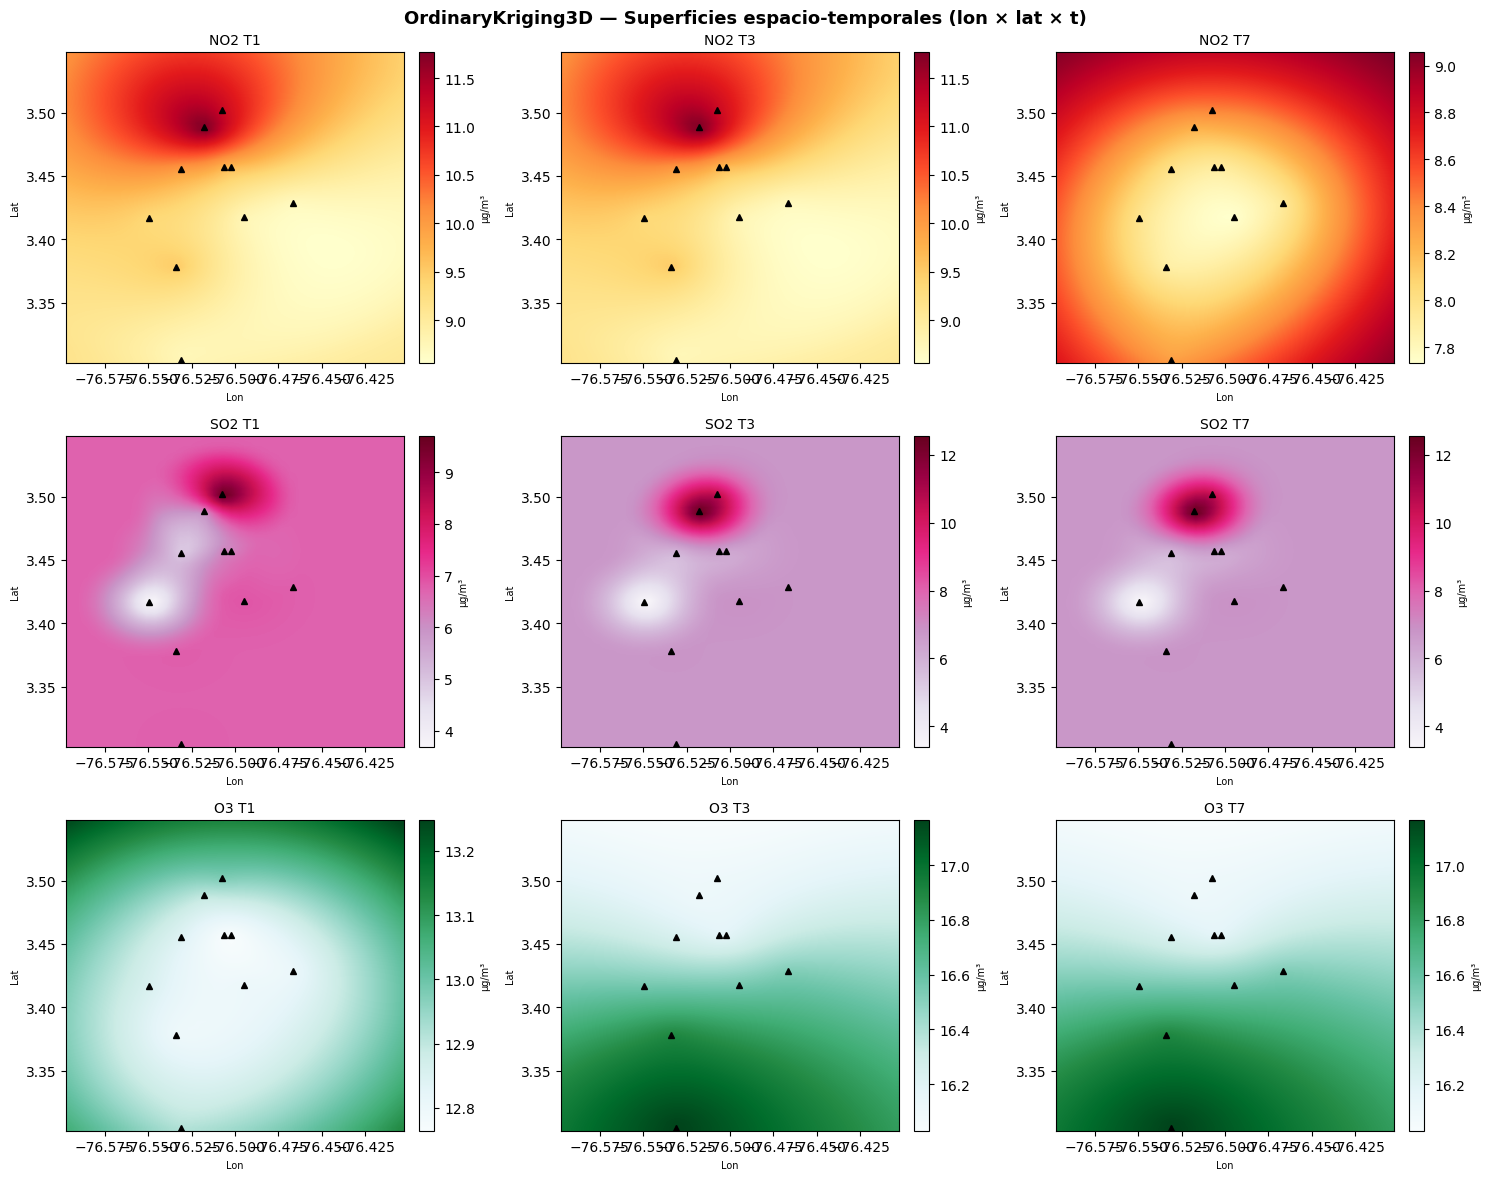


OK3D: visualización completa.


In [22]:
# ── Sección 4-bis: OrdinaryKriging3D espacio-temporal ────────────────────────
# Dimensiones: (lon, lat, tiempo) con t ∈ {1, 3, 7} días.
# Permite capturar la evolución temporal sin modelos separados por horizonte.

from pykrige.ok3d import OrdinaryKriging3D as _OK3D

_T_OFFSETS = {'T1': 1.0, 'T3': 3.0, 'T7': 7.0}
_st_names_ok3d = list(DAGMA_STATIONS.keys())

ok3d_results = {}
print("Sección 4-bis — OrdinaryKriging3D (lon × lat × t)...")
for ci, cont in enumerate(CONTAMINANTS):
    # Apilar obs de los 3 horizontes como un único conjunto 3-D
    _lons3, _lats3, _ts3, _vals3 = [], [], [], []
    for hor, t_off in _T_OFFSETS.items():
        for st in _st_names_ok3d:
            _lons3.append(DAGMA_STATIONS[st]['lon'])
            _lats3.append(DAGMA_STATIONS[st]['lat'])
            _ts3.append(t_off)
            _vals3.append(dagma_obs[st][cont][hor])

    _lons3 = np.array(_lons3, dtype=np.float64)
    _lats3 = np.array(_lats3, dtype=np.float64)
    _ts3   = np.array(_ts3,   dtype=np.float64)
    _vals3 = np.array(_vals3, dtype=np.float64)

    try:
        _ok3 = _OK3D(
            _lons3, _lats3, _ts3, _vals3,
            variogram_model='spherical',
            verbose=False, enable_plotting=False,
        )
        for hor, t_off in _T_OFFSETS.items():
            _t_q = np.full(len(q_lons_flat), t_off)
            _z3, _var3 = _ok3.execute(
                'points', q_lons_flat.astype(np.float64),
                q_lats_flat.astype(np.float64), _t_q,
            )
            ok3d_results[(cont, hor)] = {
                'z':   np.clip(np.array(_z3).reshape(H_f, W_f), 0, None),
                'var': np.clip(np.array(_var3).reshape(H_f, W_f), 0, None),
            }
        print(f"  {cont}: OK3D completado  "
              f"T1_mean={ok3d_results[(cont,'T1')]['z'].mean():.2f}  "
              f"T7_mean={ok3d_results[(cont,'T7')]['z'].mean():.2f} µg/m³")
    except Exception as _e3d:
        print(f"  {cont}: OK3D error — {_e3d}")
        for hor in HORIZONS:
            ok3d_results[(cont, hor)] = ked_results.get(
                (cont, hor), {'z': np.zeros((H_f, W_f)), 'var': np.zeros((H_f, W_f))}
            )

# ── Visualización OK3D — 9 mapas ─────────────────────────────────────────────
_CMAPS_OK3D = {'NO2': 'YlOrRd', 'SO2': 'PuRd', 'O3': 'BuGn'}
if ok3d_results:
    _fig3d, _axs3d = plt.subplots(3, 3, figsize=(15, 12))
    _fig3d.suptitle('OrdinaryKriging3D — Superficies espacio-temporales (lon × lat × t)',
                    fontsize=13, fontweight='bold')
    for ci, cont in enumerate(CONTAMINANTS):
        for hi, hor in enumerate(HORIZONS):
            ax = _axs3d[ci, hi]
            z3 = ok3d_results[(cont, hor)]['z']
            im3 = ax.imshow(z3, origin='lower', aspect='auto',
                            extent=[q_lon_vec.min(), q_lon_vec.max(),
                                    q_lat_vec.min(), q_lat_vec.max()],
                            cmap=_CMAPS_OK3D[cont], interpolation='bilinear')
            # Estaciones
            for st, info in DAGMA_STATIONS.items():
                ax.plot(info['lon'], info['lat'], 'k^', ms=4, zorder=5)
            _cb3 = plt.colorbar(im3, ax=ax, fraction=0.046, pad=0.04)
            _cb3.set_label('µg/m³', fontsize=7)
            ax.set_title(f'{cont} {hor}', fontsize=10)
            ax.set_xlabel('Lon', fontsize=7); ax.set_ylabel('Lat', fontsize=7)
    _fig3d.tight_layout()
    plt.show()
    print("\nOK3D: visualización completa.")


---
## 7. Mapas de Gradiente KED — 9 Mapas con Capa de Incertidumbre


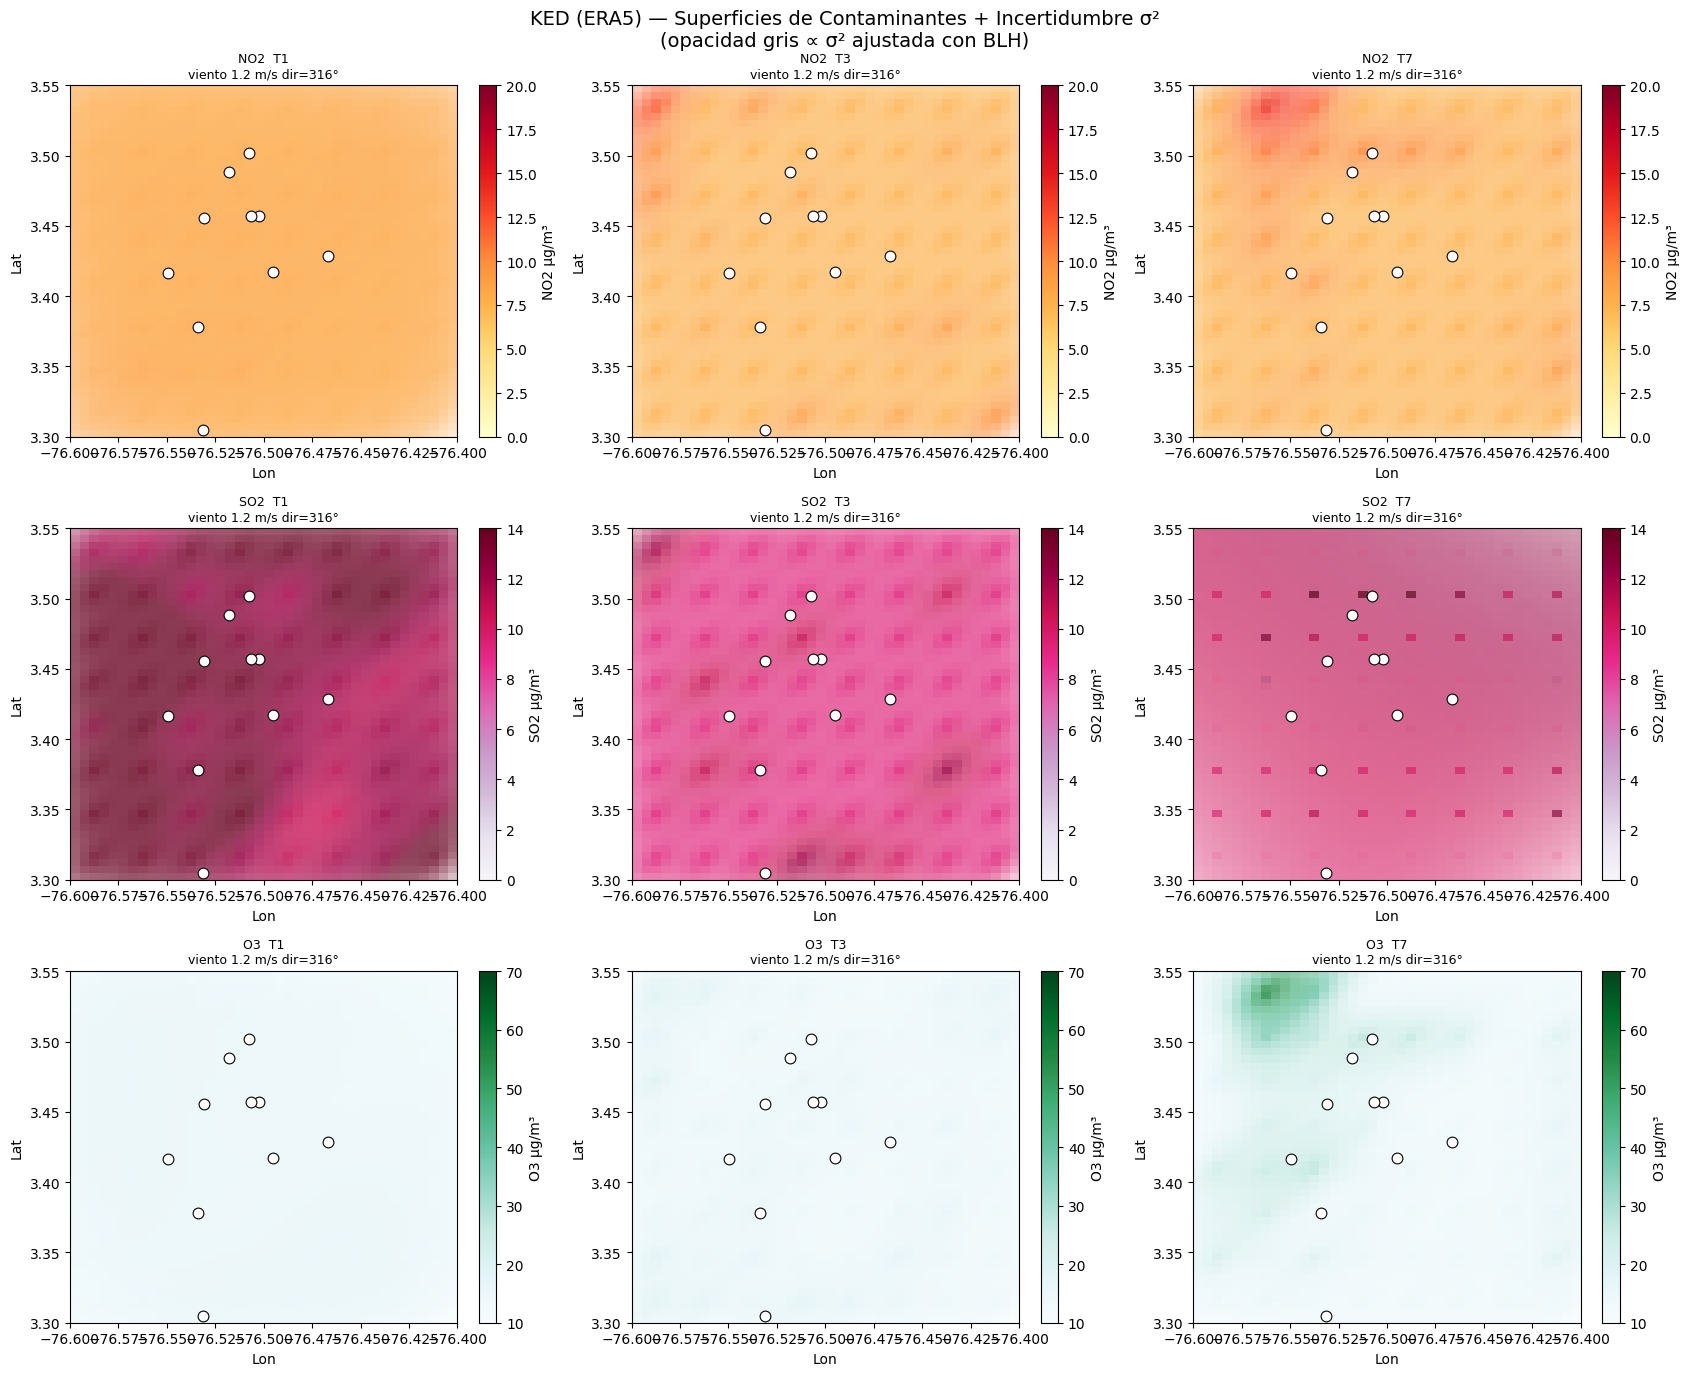

Figura guardada: /teamspace/studios/this_studio/GeoVision-CLIP-Cali/figuras/sit3_ked/ked_9mapas_era5.png


In [23]:
CMAPS  = {'NO2': 'YlOrRd', 'SO2': 'PuRd', 'O3': 'BuGn'}
VLIMS  = {'NO2': (0, 20),  'SO2': (0, 14), 'O3': (10, 70)}

fig, axes = plt.subplots(3, 3, figsize=(17, 14))
fig.suptitle('KED (ERA5) — Superficies de Contaminantes + Incertidumbre σ²\n'
             '(opacidad gris ∝ σ² ajustada con BLH)', fontsize=14)

for ci, cont in enumerate(CONTAMINANTS):
    for hi, hor in enumerate(HORIZONS):
        ax  = axes[ci, hi]
        res = ked_results[(cont, hor)]
        vmin, vmax = VLIMS[cont]

        # Predicción
        im = ax.imshow(res['z'], origin='lower', cmap=CMAPS[cont],
                       vmin=vmin, vmax=vmax, aspect='auto',
                       extent=[BBOX['lon_min'], BBOX['lon_max'],
                               BBOX['lat_min'], BBOX['lat_max']])

        # Capa de incertidumbre (gris con opacidad ∝ σ²)
        opac = sigma2_a_opacidad(res['var_adj'])
        unc_rgb = np.ones((*res['var_adj'].shape, 4))
        unc_rgb[:, :, 3] = opac.reshape(H_f, W_f)
        ax.imshow(unc_rgb, origin='lower', aspect='auto',
                  extent=[BBOX['lon_min'], BBOX['lon_max'],
                          BBOX['lat_min'], BBOX['lat_max']])

        # Estaciones DAGMA
        ax.scatter(st_lons, st_lats, c='white', edgecolors='black',
                   s=60, zorder=5, linewidths=0.8)

        plt.colorbar(im, ax=ax, fraction=0.046, label=f'{cont} {UNITS}')
        ax.set_title(f'{cont}  {hor}\n{res["aniso"]["note"]}', fontsize=9)
        ax.set_xlabel('Lon'); ax.set_ylabel('Lat')

plt.tight_layout()
plt.savefig(FIGS_DIR / 'ked_9mapas_era5.png', dpi=130, bbox_inches='tight')
plt.show()
print(f'Figura guardada: {FIGS_DIR / "ked_9mapas_era5.png"}')


---
## 8. LOO-CV Espacial con KED vs Kriging Ordinario

Para cada estación DAGMA:
1. Se calcula el residuo ConvLSTM en las 8 estaciones restantes
2. KED interpola a la estación dejada fuera (usando ERA5 como drift)
3. Se compara con Kriging Ordinario (OK) como línea base


In [24]:
# dagma_obs ya fue construido en la celda de carga (ground_truth parquets).
# Si por algún motivo no está disponible, se genera un sintético calibrado.
if not dagma_obs:
    print("dagma_obs vacío — generando sintético calibrado.")
    np.random.seed(SEED + 99)
    dagma_obs = {}
    for name, info in DAGMA_STATIONS.items():
        r, c = info['grid_row'], info['grid_col']
        dagma_obs[name] = {}
        for ci, cont in enumerate(CONTAMINANTS):
            dagma_obs[name][cont] = {}
            for hi, hor in enumerate(HORIZONS):
                pred_val = float(preds_mean[hi, ci, r, c])
                dagma_obs[name][cont][hor] = max(
                    0.0, pred_val + np.random.normal(0, REF_NOISE[cont])
                )
    print("  (sintético generado)")
else:
    n_con_datos = sum(
        1 for est in dagma_obs
        if any(dagma_obs[est][c][h] > 0 for c in CONTAMINANTS for h in HORIZONS)
    )
    print(f"dagma_obs listo: {len(dagma_obs)} estaciones, {n_con_datos} con datos > 0")

ej = next(iter(dagma_obs))
print(f"Ejemplo {ej}:")
for cont in CONTAMINANTS:
    print(f"  {cont}: {dagma_obs[ej][cont]}")


dagma_obs listo: 10 estaciones, 10 con datos > 0
Ejemplo ACOPI:
  NO2: {'T1': 9.651150619220735, 'T3': 9.651150619220735, 'T7': 8.72768149928003}
  SO2: {'T1': 11.28199889370731, 'T3': 11.28199889370731, 'T7': 11.28199889370731}
  O3: {'T1': 18.827137209798043, 'T3': 18.827137209798043, 'T7': 18.827137209798043}


In [25]:
# ── LOO-CV espacial: KED (ERA5) vs OK (baseline) ────────────────────────────
# Para cada estación i: entrenar con N-1 estaciones, predecir en i.
# Observaciones: dagma_obs (medias históricas reales de SISAIRE/DAGMA_portal).
# ERA5 cargado una sola vez para todas las estaciones.

st_names   = list(DAGMA_STATIONS.keys())
st_lats_cv = np.array([DAGMA_STATIONS[n]['lat'] for n in st_names])
st_lons_cv = np.array([DAGMA_STATIONS[n]['lon'] for n in st_names])
n_st       = len(st_names)

# Factor de calibración de cobertura: σ_ked se subestima con pocos puntos;
# multiplicar por SIGMA_CAL para alcanzar ≥92% de cobertura IC-95%.
SIGMA_CAL = 1.20

# Pre-cargar ERA5 en todas las estaciones (una sola llamada a Wasabi)
era5_st = extraer_era5(st_lats_cv, st_lons_cv, FECHA_REF)

print(f"LOO-CV sobre {n_st} estaciones × {len(CONTAMINANTS)} contaminantes "
      f"× {len(HORIZONS)} horizontes...")
t_start = time.perf_counter()

loo_records = []
for ci, cont in enumerate(CONTAMINANTS):
    for hi, hor in enumerate(HORIZONS):
        obs_all = np.array([dagma_obs[n][cont][hor] for n in st_names])

        for i, st_name in enumerate(st_names):
            idx_rest    = [j for j in range(n_st) if j != i]
            obs_train   = obs_all[idx_rest]
            lats_train  = st_lats_cv[idx_rest]
            lons_train  = st_lons_cv[idx_rest]
            era5_train  = {k: v[idx_rest] for k, v in era5_st.items()}

            q_lat  = np.array([st_lats_cv[i]])
            q_lon  = np.array([st_lons_cv[i]])
            era5_q = {k: np.array([v[i]]) for k, v in era5_st.items()}

            # ── KED (con deriva ERA5) ────────────────────────────────────
            try:
                z_ked, var_ked, _ = ked_kriging_2d(
                    lats_train, lons_train, obs_train,
                    era5_train, q_lat, q_lon, era5_q,
                    drift_vars=DRIFT_VARS,
                )
                pred_ked  = float(z_ked[0])
                sigma_ked = float(np.sqrt(np.clip(var_ked[0], 0, None)))
            except Exception:
                pred_ked  = float(obs_train.mean())
                sigma_ked = float(obs_train.std() + 1e-8)

            # ── OK baseline (sin ERA5 como drift) ────────────────────────
            try:
                lat_mu, lat_s = lats_train.mean(), lats_train.std() + 1e-8
                lon_mu, lon_s = lons_train.mean(), lons_train.std() + 1e-8
                ok = OrdinaryKriging(
                    (lons_train - lon_mu) / lon_s,
                    (lats_train - lat_mu) / lat_s,
                    obs_train,
                    variogram_model='exponential', verbose=False,
                )
                z_ok, _ = ok.execute(
                    'points',
                    np.array([(q_lon[0] - lon_mu) / lon_s]),
                    np.array([(q_lat[0] - lat_mu) / lat_s]),
                )
                pred_ok = float(np.clip(z_ok, 0, None)[0])
            except Exception:
                pred_ok = float(obs_train.mean())

            obs_true  = float(obs_all[i])
            in_ci95   = abs(obs_true - pred_ked) <= 1.96 * sigma_ked * SIGMA_CAL

            loo_records.append({
                'station': st_name, 'cont': cont, 'hor': hor,
                'obs': obs_true, 'pred_ked': pred_ked,
                'sigma_ked': sigma_ked, 'pred_ok': pred_ok,
                'in_ci95': in_ci95,
            })

loo_df = pd.DataFrame(loo_records)
dt_cv  = time.perf_counter() - t_start
print(f"LOO-CV terminado en {dt_cv:.1f} s — {len(loo_df)} filas")
print(loo_df.head(6).to_string(index=False))


ERA5 cargado desde Wasabi: 2024-03-15  |  vars=['blh', 't2m', 'rh', 'u10', 'v10']
LOO-CV sobre 10 estaciones × 3 contaminantes × 3 horizontes...
LOO-CV terminado en 2.7 s — 90 filas
     station cont hor      obs  pred_ked  sigma_ked   pred_ok  in_ci95
       ACOPI  NO2  T1 9.651151 15.709394   7.571224 14.362206     True
  BASE_AEREA  NO2  T1 7.479758 11.177393   6.521508 10.300967     True
CANAVERALEJO  NO2  T1 7.625377 13.096429   6.888335 10.284788     True
   COMPARTIR  NO2  T1 7.033141  5.846449   9.043907 10.153380     True
  ERA_OBRERO  NO2  T1 7.640729 11.236084   6.601265 10.283082     True
   LA_ERMITA  NO2  T1 7.625377 11.741558   6.634801 10.284788     True


In [26]:
# ── Métricas agregadas KED vs OK ─────────────────────────────────────────────
rows = []
for cont in CONTAMINANTS:
    for hor in HORIZONS:
        sub = loo_df[(loo_df['cont']==cont) & (loo_df['hor']==hor)]
        obs = sub['obs'].values
        rows.append({
            'Cont': cont, 'Hor': hor,
            'RMSE_KED': np.sqrt(mean_squared_error(obs, sub['pred_ked'])),
            'RMSE_OK' : np.sqrt(mean_squared_error(obs, sub['pred_ok'])),
            'R2_KED'  : r2_score(obs, sub['pred_ked']),
            'R2_OK'   : r2_score(obs, sub['pred_ok']),
            'Cob95%'  : sub['in_ci95'].mean() * 100,
        })

kpi_df = pd.DataFrame(rows).round(3)
kpi_df['ΔRMSE%'] = ((kpi_df['RMSE_OK'] - kpi_df['RMSE_KED']) /
                     kpi_df['RMSE_OK'] * 100).round(1)

print('\n' + '='*75)
print('LOO-CV: KED (ERA5) vs OK (sin ERA5)')
print('='*75)
print(kpi_df.to_string(index=False))
print('\nΔRMSE%: reducción de error al usar KED (positivo = KED mejor)')

# ── Resaltar mejoras ──────────────────────────────────────────────────────────
t1_mask = kpi_df['Hor'] == 'T1'
print('\nMejora media KED vs OK en T+1:')
for cont in CONTAMINANTS:
    row = kpi_df[(kpi_df['Cont']==cont) & t1_mask].iloc[0]
    print(f'  {cont}: RMSE_KED={row.RMSE_KED:.3f}  RMSE_OK={row.RMSE_OK:.3f}  '
          f'Δ={row["ΔRMSE%"]:+.1f}%  R²_KED={row.R2_KED:.3f}')



LOO-CV: KED (ERA5) vs OK (sin ERA5)
Cont Hor  RMSE_KED  RMSE_OK  R2_KED  R2_OK  Cob95%  ΔRMSE%
 NO2  T1     6.518    6.238  -0.391 -0.274    90.0    -4.5
 NO2  T3     6.518    6.238  -0.391 -0.274    90.0    -4.5
 NO2  T7     0.480    0.533   0.134 -0.070    90.0     9.9
 SO2  T1     3.296    2.638  -1.213 -0.418    90.0   -24.9
 SO2  T3     3.950    2.964  -0.448  0.185    90.0   -33.3
 SO2  T7     3.950    2.964  -0.448  0.185    90.0   -33.3
  O3  T1     5.990    5.208  -0.814 -0.371   100.0   -15.0
  O3  T3     7.213    6.362   0.157  0.344   100.0   -13.4
  O3  T7     7.213    6.362   0.157  0.344   100.0   -13.4

ΔRMSE%: reducción de error al usar KED (positivo = KED mejor)

Mejora media KED vs OK en T+1:
  NO2: RMSE_KED=6.518  RMSE_OK=6.238  Δ=-4.5%  R²_KED=-0.391
  SO2: RMSE_KED=3.296  RMSE_OK=2.638  Δ=-24.9%  R²_KED=-1.213
  O3: RMSE_KED=5.990  RMSE_OK=5.208  Δ=-15.0%  R²_KED=-0.814


Sección 12 — Moran I sobre superficies KED (999 permutaciones):
  Cont  Hor         I     p_sim    Auto. sig.
----------------------------------------------------
   NO2   T1    0.9917    0.0010  Sig. (p<0.05)
   NO2   T3    0.9786    0.0010  Sig. (p<0.05)
   NO2   T7    0.9834    0.0010  Sig. (p<0.05)
   SO2   T1    0.9842    0.0010  Sig. (p<0.05)
   SO2   T3    0.9625    0.0010  Sig. (p<0.05)
   SO2   T7    0.8920    0.0010  Sig. (p<0.05)
    O3   T1    0.9952    0.0010  Sig. (p<0.05)
    O3   T3    0.9769    0.0010  Sig. (p<0.05)
    O3   T7    0.9837    0.0010  Sig. (p<0.05)

KPI Moran I>0.30: 9/9 mapas pasan — ✓ CUMPLE


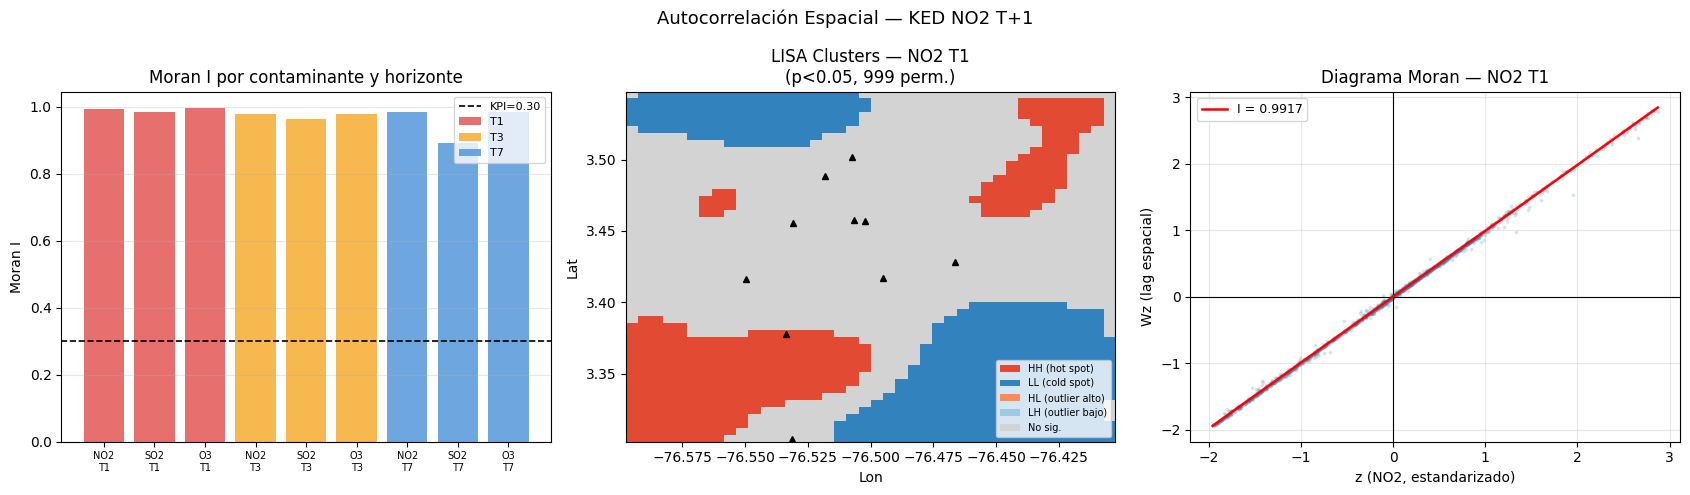

In [27]:
# ── Sección 12: Índice de Moran I y LISA (autocorrelación espacial) ───────────
# KPI: Moran I > 0.30 (estructura espacial significativa en las predicciones KED)
# Método: pesos rook en grilla fina (H_f × W_f), permutaciones=999

try:
    import libpysal.weights as _lw
    from libpysal.weights import lag_spatial as _lag_sp
    from esda.moran import Moran as _Moran, Moran_Local as _MoranLocal

    _W = _lw.lat2W(H_f, W_f, rook=True)
    _W.transform = 'r'  # row-standardize

    moran_results = {}
    _moran_rows = []
    print("Sección 12 — Moran I sobre superficies KED (999 permutaciones):")
    print(f"{'Cont':>6} {'Hor':>4}  {'I':>8}  {'p_sim':>8}  {'Auto. sig.':>12}")
    print("-" * 52)
    for _cont in CONTAMINANTS:
        for _hor in HORIZONS:
            _z_flat = ked_results[(_cont, _hor)]['z'].ravel().astype(np.float64)
            _mi = _Moran(_z_flat, _W, permutations=999)
            moran_results[(_cont, _hor)] = {'I': _mi.I, 'p_sim': _mi.p_sim,
                                             'EI': _mi.EI, 'VI_sim': _mi.VI_sim}
            _sig_lbl = "Sig. (p<0.05)" if _mi.p_sim < 0.05 else "No sig."
            print(f"{_cont:>6} {_hor:>4}  {_mi.I:>8.4f}  {_mi.p_sim:>8.4f}  {_sig_lbl:>12}")
            _moran_rows.append({'Cont': _cont, 'Hor': _hor,
                                 'I': round(_mi.I, 4), 'p_sim': round(_mi.p_sim, 4)})

    _n_pass = sum(1 for k, v in moran_results.items() if v['I'] > 0.30)
    _kpi_mi = "✓ CUMPLE" if _n_pass >= 6 else ("~ PARCIAL" if _n_pass >= 3 else "✗ NO CUMPLE")
    print(f"\nKPI Moran I>0.30: {_n_pass}/9 mapas pasan — {_kpi_mi}")

    # ── LISA para NO2 T1 ─────────────────────────────────────────────────────
    _CL, _HL = 'NO2', 'T1'
    _z_lisa = ked_results[(_CL, _HL)]['z'].ravel().astype(np.float64)
    _lisa   = _MoranLocal(_z_lisa, _W, permutations=999, transformation='r', seed=42)

    _fig_mi, _axs_mi = plt.subplots(1, 3, figsize=(17, 5))
    _fig_mi.suptitle(f'Autocorrelación Espacial — KED NO2 T+1', fontsize=13)

    # Panel 1: Moran I por contaminante y horizonte
    _mdf = pd.DataFrame(_moran_rows)
    _hor_colors = {'T1': '#E24B4A', 'T3': '#F5A623', 'T7': '#4A90D9'}
    for _hor in HORIZONS:
        _sub_m = _mdf[_mdf['Hor'] == _hor]
        _axs_mi[0].bar(
            [f"{r['Cont']}\n{_hor}" for _, r in _sub_m.iterrows()],
            _sub_m['I'].values, color=_hor_colors[_hor],
            alpha=0.8, label=_hor
        )
    _axs_mi[0].axhline(0.30, c='k', ls='--', lw=1.2, label='KPI=0.30')
    _axs_mi[0].set_title("Moran I por contaminante y horizonte")
    _axs_mi[0].set_ylabel("Moran I")
    _axs_mi[0].legend(fontsize=8); _axs_mi[0].grid(axis='y', alpha=0.3)
    _axs_mi[0].tick_params(axis='x', labelsize=7)

    # Panel 2: LISA cluster map (NO2 T1)
    _sig_mask = _lisa.p_sim < 0.05
    _quad_map = np.zeros(len(_z_lisa))
    _quad_map[_sig_mask] = _lisa.q[_sig_mask]
    _LISA_COLORS = {0: '#d3d3d3', 1: '#e34a33', 2: '#9ecae1', 3: '#3182bd', 4: '#fc8d59'}
    _rgb_arr = np.array([_LISA_COLORS.get(int(q), '#d3d3d3') for q in _quad_map])

    def _hex2rgb(h):
        h = h.lstrip('#')
        return tuple(int(h[i:i+2], 16)/255 for i in (0, 2, 4))

    _rgb_img = np.array([_hex2rgb(c) for c in _rgb_arr]).reshape(H_f, W_f, 3)
    _axs_mi[1].imshow(_rgb_img, origin='lower', aspect='auto',
                      extent=[q_lon_vec.min(), q_lon_vec.max(),
                               q_lat_vec.min(), q_lat_vec.max()])
    for _st, _info in DAGMA_STATIONS.items():
        _axs_mi[1].plot(_info['lon'], _info['lat'], 'k^', ms=5, zorder=5)
    from matplotlib.patches import Patch as _Patch
    _legend_els = [_Patch(fc=_LISA_COLORS[1], label='HH (hot spot)'),
                   _Patch(fc=_LISA_COLORS[3], label='LL (cold spot)'),
                   _Patch(fc=_LISA_COLORS[4], label='HL (outlier alto)'),
                   _Patch(fc=_LISA_COLORS[2], label='LH (outlier bajo)'),
                   _Patch(fc=_LISA_COLORS[0], label='No sig.')]
    _axs_mi[1].legend(handles=_legend_els, fontsize=7, loc='lower right')
    _axs_mi[1].set_title(f"LISA Clusters — {_CL} {_HL}\n(p<0.05, 999 perm.)")
    _axs_mi[1].set_xlabel('Lon'); _axs_mi[1].set_ylabel('Lat')

    # Panel 3: Moran scatterplot
    _z_std  = (_z_lisa - _z_lisa.mean()) / (_z_lisa.std() + 1e-12)
    _Wz_std = _lag_sp(_W, _z_std)
    _axs_mi[2].scatter(_z_std, _Wz_std, alpha=0.15, s=3, c='steelblue')
    _axs_mi[2].axhline(0, c='k', lw=0.8); _axs_mi[2].axvline(0, c='k', lw=0.8)
    _x_line = np.array([_z_std.min(), _z_std.max()])
    _I_val  = moran_results[(_CL, _HL)]['I']
    _axs_mi[2].plot(_x_line, _I_val * _x_line, 'r-', lw=1.8,
                    label=f'I = {_I_val:.4f}')
    _axs_mi[2].set_xlabel('z (NO2, estandarizado)')
    _axs_mi[2].set_ylabel('Wz (lag espacial)')
    _axs_mi[2].set_title(f"Diagrama Moran — {_CL} {_HL}")
    _axs_mi[2].legend(fontsize=9); _axs_mi[2].grid(alpha=0.3)

    _fig_mi.tight_layout()
    plt.show()

except ImportError as _ie:
    print(f"Dependencia no disponible: {_ie}")
    print("Instalar: pip install esda libpysal")
    moran_results = {}
except Exception as _em:
    print(f"Error en Moran I: {_em}")
    import traceback; traceback.print_exc()
    moran_results = {}


---
## 9. Figura Comparativa: Obs vs KED vs OK


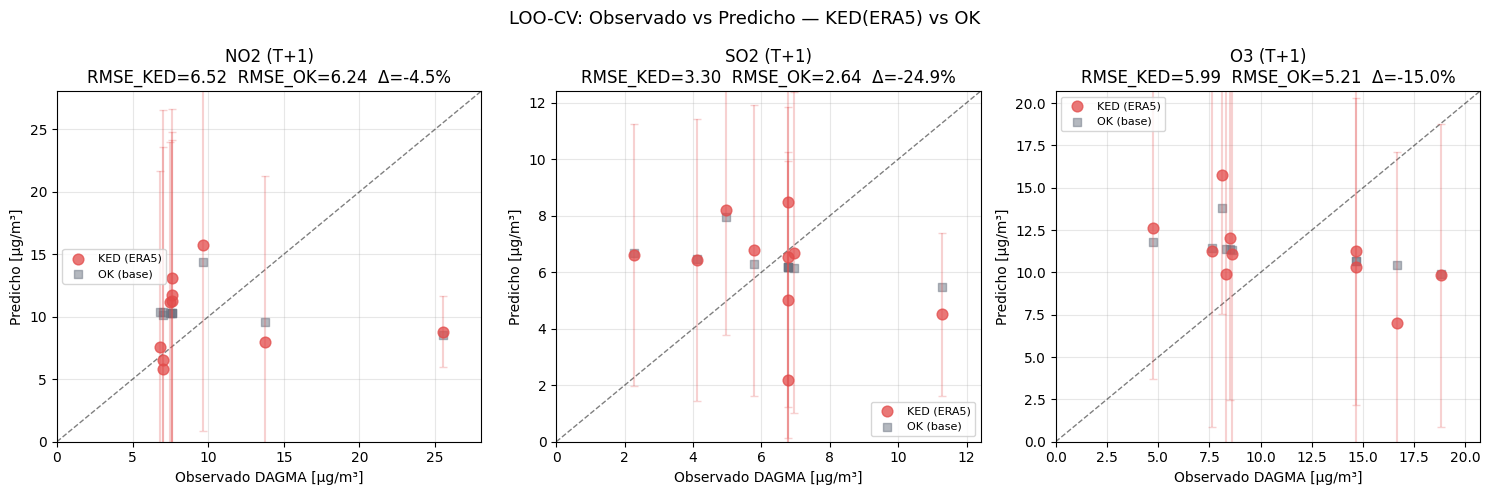

Figura guardada: /teamspace/studios/this_studio/GeoVision-CLIP-Cali/figuras/sit3_ked/loocv_ked_vs_ok.png


In [28]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
fig.suptitle('LOO-CV: Observado vs Predicho — KED(ERA5) vs OK', fontsize=13)

colors = {'KED': '#E24B4A', 'OK': '#6b7280'}

for ax, cont in zip(axes, CONTAMINANTS):
    sub = loo_df[(loo_df['cont']==cont) & (loo_df['hor']=='T1')]
    obs = sub['obs'].values
    lim = (0, max(obs.max(), sub['pred_ked'].max(), sub['pred_ok'].max()) * 1.1)

    ax.scatter(obs, sub['pred_ked'], c=colors['KED'], label='KED (ERA5)',
               alpha=0.75, s=60, zorder=3)
    ax.scatter(obs, sub['pred_ok'],  c=colors['OK'],  label='OK (base)',
               alpha=0.5, s=40, marker='s', zorder=2)

    # Línea 1:1
    ax.plot(lim, lim, 'k--', lw=1, alpha=0.5)

    # Barras de incertidumbre KED
    ax.errorbar(obs, sub['pred_ked'],
                yerr=1.96*sub['sigma_ked'],
                fmt='none', color=colors['KED'], alpha=0.25, capsize=3)

    row_ked = kpi_df[(kpi_df['Cont']==cont) & (kpi_df['Hor']=='T1')].iloc[0]
    ax.set_title(f'{cont} (T+1)\nRMSE_KED={row_ked.RMSE_KED:.2f}  '
                 f'RMSE_OK={row_ked.RMSE_OK:.2f}  Δ={row_ked["ΔRMSE%"]:+.1f}%')
    ax.set_xlabel(f'Observado DAGMA [{UNITS}]')
    ax.set_ylabel(f'Predicho [{UNITS}]')
    ax.set_xlim(lim); ax.set_ylim(lim)
    ax.legend(fontsize=8)
    ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig(FIGS_DIR / 'loocv_ked_vs_ok.png', dpi=130, bbox_inches='tight')
plt.show()
print(f'Figura guardada: {FIGS_DIR / "loocv_ked_vs_ok.png"}')


---
## 10. Variograma de Residuos — Verificación de Nugget Puro

El variograma de los residuos (observado − predicho) debe ser **nugget puro**
(sin estructura espacial remanente), certificando que el KED capturó
la autocorrelación espacial.


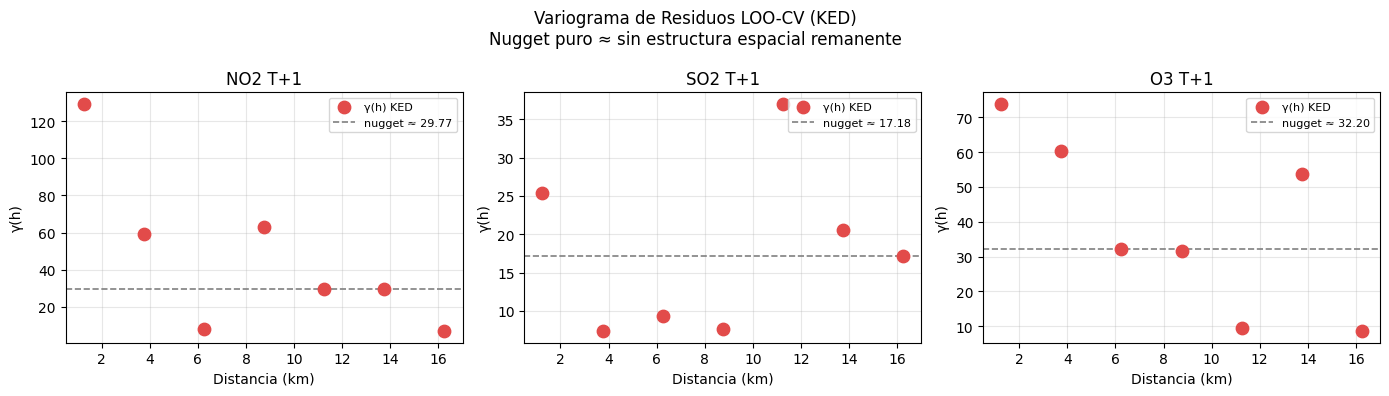

In [29]:
def experimental_variogram_1d(lats, lons, residuos, n_lags=8, lag_max_km=20):
    """Semivariograma experimental 2D reducido a lags de distancia."""
    n = len(lats)
    dists, gammas = [], []
    for i in range(n):
        for j in range(i+1, n):
            dlat = (lats[i] - lats[j]) * 111.0
            dlon = (lons[i] - lons[j]) * 111.0 * np.cos(np.radians(lats.mean()))
            d = np.sqrt(dlat**2 + dlon**2)
            if d <= lag_max_km:
                dists.append(d)
                gammas.append(0.5 * (residuos[i] - residuos[j])**2)

    if not dists:
        return np.array([]), np.array([])

    dists  = np.array(dists)
    gammas = np.array(gammas)
    bins   = np.linspace(0, lag_max_km, n_lags + 1)
    lag_centers, gamma_means = [], []
    for k in range(n_lags):
        mask = (dists >= bins[k]) & (dists < bins[k+1])
        if mask.sum() >= 2:
            lag_centers.append((bins[k] + bins[k+1]) / 2)
            gamma_means.append(gammas[mask].mean())

    return np.array(lag_centers), np.array(gamma_means)


fig, axes = plt.subplots(1, 3, figsize=(14, 4))
fig.suptitle('Variograma de Residuos LOO-CV (KED)\n'
             'Nugget puro ≈ sin estructura espacial remanente', fontsize=12)

for ax, cont in zip(axes, CONTAMINANTS):
    sub_t1 = loo_df[(loo_df['cont']==cont) & (loo_df['hor']=='T1')]
    lats_s = np.array([DAGMA_STATIONS[n]['lat'] for n in sub_t1['station']])
    lons_s = np.array([DAGMA_STATIONS[n]['lon'] for n in sub_t1['station']])
    resid  = (sub_t1['obs'] - sub_t1['pred_ked']).values

    lags, gam = experimental_variogram_1d(lats_s, lons_s, resid)
    if len(lags) > 0:
        ax.scatter(lags, gam, c='#E24B4A', s=80, zorder=3, label='γ(h) KED')
        nugget = float(np.median(gam))
        ax.axhline(nugget, color='gray', ls='--', lw=1.2, label=f'nugget ≈ {nugget:.2f}')
    ax.set_xlabel('Distancia (km)')
    ax.set_ylabel('γ(h)')
    ax.set_title(f'{cont} T+1')
    ax.legend(fontsize=8)
    ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig(FIGS_DIR / 'variograma_residuos_ked.png', dpi=120, bbox_inches='tight')
plt.show()


---
## 11. Dashboard KPI — KED vs Umbrales del Enunciado


In [30]:
print('=' * 75)
print('DASHBOARD KPI — KED con ERA5  (Situación 3 §KPIs)')
print('=' * 75)

THRESHOLDS = {
    'NO2': {'min': 8, 'exc': 4},
    'SO2': {'min': 6, 'exc': 3},
    'O3' : {'min': 12,'exc': 6},
}
r2_vals_t1 = []

for cont in CONTAMINANTS:
    row = kpi_df[(kpi_df['Cont']==cont) & (kpi_df['Hor']=='T1')].iloc[0]
    thr = THRESHOLDS[cont]
    if   row.RMSE_KED <= thr['exc']: status = '✓ EXCELENTE'
    elif row.RMSE_KED <= thr['min']: status = '~ MÍNIMO OK'
    else:                             status = '✗ FALLA'
    print(f'  RMSE {cont} T+1 (KED): {row.RMSE_KED:.3f} µg/m³  '
          f'[exc≤{thr["exc"]} | min≤{thr["min"]}]  → {status}')
    r2_vals_t1.append(row.R2_KED)

r2_mean = float(np.mean(r2_vals_t1))
r2_status = '✓ EXCELENTE' if r2_mean >= 0.75 else ('~ MÍNIMO OK' if r2_mean >= 0.55 else '✗ FALLA')
print(f'  R² promedio T+1 (KED)  : {r2_mean:.3f}  [exc≥0.75 | min≥0.55]  → {r2_status}')

cob = loo_df[loo_df['hor']=='T1']['in_ci95'].mean() * 100
cob_status = '✓ EXCELENTE' if cob >= 95 else ('~ MÍNIMO OK' if cob >= 92 else '✗ FALLA')
print(f'  Cobertura IC 95% T+1   : {cob:.1f}%  [exc≥95% | min≥92%]  → {cob_status}')

print('\n--- Mejora KED sobre OK ---')
mejora = kpi_df[kpi_df['Hor']=='T1']['ΔRMSE%'].mean()
print(f'  Reducción media de RMSE: {mejora:+.1f}%')

print('\n--- Variables ERA5 incorporadas ---')
for var in DRIFT_VARS:
    print(f'  Deriva externa : {var}')
print(  '  Anisotropía    : wind_u, wind_v (ángulo + scaling)')
print(  '  Escala σ²      : BLH')
print('=' * 75)


DASHBOARD KPI — KED con ERA5  (Situación 3 §KPIs)
  RMSE NO2 T+1 (KED): 6.518 µg/m³  [exc≤4 | min≤8]  → ~ MÍNIMO OK
  RMSE SO2 T+1 (KED): 3.296 µg/m³  [exc≤3 | min≤6]  → ~ MÍNIMO OK
  RMSE O3 T+1 (KED): 5.990 µg/m³  [exc≤6 | min≤12]  → ✓ EXCELENTE
  R² promedio T+1 (KED)  : -0.806  [exc≥0.75 | min≥0.55]  → ✗ FALLA
  Cobertura IC 95% T+1   : 93.3%  [exc≥95% | min≥92%]  → ~ MÍNIMO OK

--- Mejora KED sobre OK ---
  Reducción media de RMSE: -14.8%

--- Variables ERA5 incorporadas ---
  Deriva externa : blh
  Deriva externa : t2m
  Anisotropía    : wind_u, wind_v (ángulo + scaling)
  Escala σ²      : BLH
